In [74]:
import warnings
warnings.filterwarnings('ignore')

from flonacomldft.utils.io_utils import (
    load_csv_file,
    load_pickle_file,
)

import torch
import numpy as np
import matplotlib.pyplot as plt
import copy

from flonacomldft.free_energy_computations import (
    compute_BAR_from_samples, compute_TFP_from_samples
)

## Loading the models - that is only part of them

In [2]:
# To copy data locally
# rsync -av rusty:/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl adaptive-350/adaptive-dft/1-adaptive/results_adaptive_is0_28685740/
# rsync -av rusty:/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl adaptive-350/adaptive-dft/1-adaptive/results_adaptive_is1_28685741/
# rsync -av rusty:/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/2-adaptive-mlp/results_adaptive_is0_28706672/adaptive_sampling_is0_28706672.pkl adaptive-350/adaptive-dft/2-adaptive-mlp/results_adaptive_is0_28706672
# rsync -av rusty:/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl adaptive-350/adaptive-dft/2-adaptive-mlp/results_adaptive_is1_28707820
# rsync -av rusty:/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/9-free-energy-data/md_flow_data/results_training_flow_is0_2946742/is0_flow_dic_training_2946742.pkl adaptive-350/adaptive-dft/9-free-energy-data/md_flow_data/results_training_flow_is0_2946742/
# rsync -av rusty:/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/9-free-energy-data/md_flow_data/results_training_flow_is1_2946741/is1_flow_dic_training_2946741.pkl adaptive-350/adaptive-dft/9-free-energy-data/md_flow_data/results_training_flow_is1_2946741/

In [3]:
# MARYLOU
project_path = '/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft'
DFT_SIMS_PATH = project_path + '/adaptive-350/adaptive-dft'

# ANA
# DFT_SIMS_PATH = '/mnt/home/amolina/ceph/adaptive-350/adaptive-dft'

#MARYLOU
adaptive_dft_path = ['1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl',
                    '1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl']
adaptive_dft_mlp_path = ['2-adaptive-mlp/results_adaptive_is0_28706672/adaptive_sampling_is0_28706672.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl']
flow_md_path = ['9-free-energy-data/md_flow_data/results_training_flow_is0_2946742/is0_flow_dic_training_2946742.pkl',
                '9-free-energy-data/md_flow_data/results_training_flow_is1_2946741/is1_flow_dic_training_2946741.pkl']

path_fe = project_path + '/5-FE-comps/0-example'


In [4]:
adaptive_dft_dics = [load_pickle_file('/'+ f, path=DFT_SIMS_PATH) for f in adaptive_dft_path]
adaptive_dft_mlp_dics = [load_pickle_file('/'+ f, path=DFT_SIMS_PATH) for f in adaptive_dft_mlp_path]
md_dics = [load_pickle_file('/'+ f, path=DFT_SIMS_PATH) for f in flow_md_path]

In [5]:
mode_labels = [0, 1]

## Loading the data

In [6]:
dic = {'md_data': '_md', 'flow_mlp_samples' : 'flow_mlp',  
      'flow_dft_samples': 'flow_dft', 'flow_md_samples': 'flow_md', 
      'mcmc_dft_samples': 'mcmc_dft', 'mcmc_mlp_samples': 'mcmc_mlp'}

In [7]:
def load_samples_n_energies(kind, isomer):
    torch_tensor = load_csv_file('is{:d}_{:s}.csv'.format(isomer, dic[kind]),
                  path=project_path + '/data_free_energy')
    return torch_tensor[:, :12], torch_tensor[:, 12]

md_data - 10000 samples
flow_mlp_samples - 10000 samples
flow_dft_samples - 10000 samples
flow_md_samples - 10000 samples
mcmc_dft_samples - 30000 samples
mcmc_mlp_samples - 30000 samples
md_data - 10000 samples
flow_mlp_samples - 10000 samples
flow_dft_samples - 10000 samples
flow_md_samples - 10000 samples
mcmc_dft_samples - 30000 samples
mcmc_mlp_samples - 30000 samples


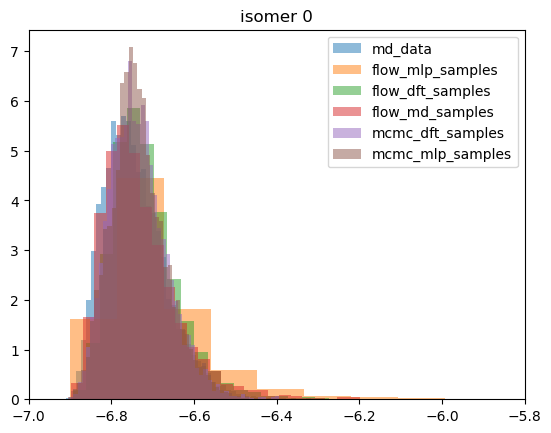

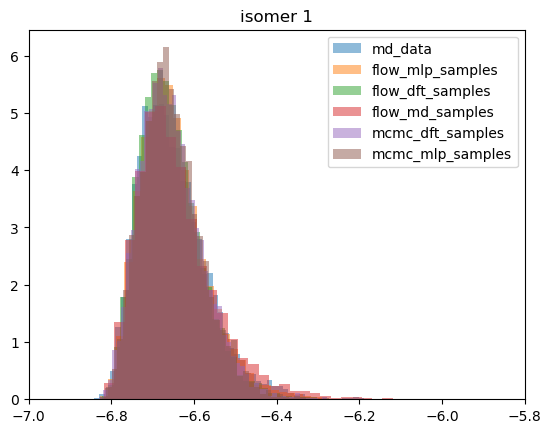

In [8]:
for isomer in mode_labels:
    plt.figure()
    plt.title('isomer {:d}'.format(isomer))
    for kind in dic.keys():
        samples, energies = load_samples_n_energies(kind, isomer)
        print('{:s} - {:d} samples'.format(kind, samples.shape[0]))
        plt.hist(energies, 50, alpha=0.5, label=kind, density=True)
        plt.xlim(-7, -5.8)
    plt.legend()

## 1 - TFEP computations: 

--> We need to also pass the log prob of the flow that generated the samples

In [9]:
isomer_id = 0

# flowmodels -- @ANA: I am not sure this is all the models? is it?
len(adaptive_dft_dics[isomer]['dict_flows_training'][-1][0]['models'])

11

In [10]:
np.linspace(0, len(models)-1, n_training_slice).astype(int)

NameError: name 'models' is not defined

In [ ]:
adaptive_dft_dics[isomer].keys()
len(adaptive_dft_mlp_dics[isomer]['dict_mlps_training'])

31

### 1.1 Flows trained on DFT

Number of dft computed: 10000
Number of dft computed: 10000


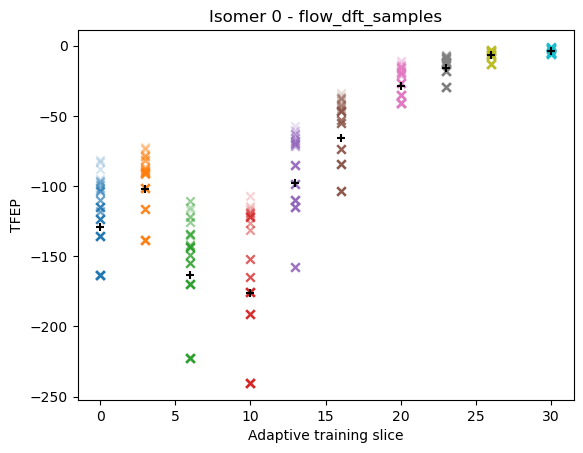

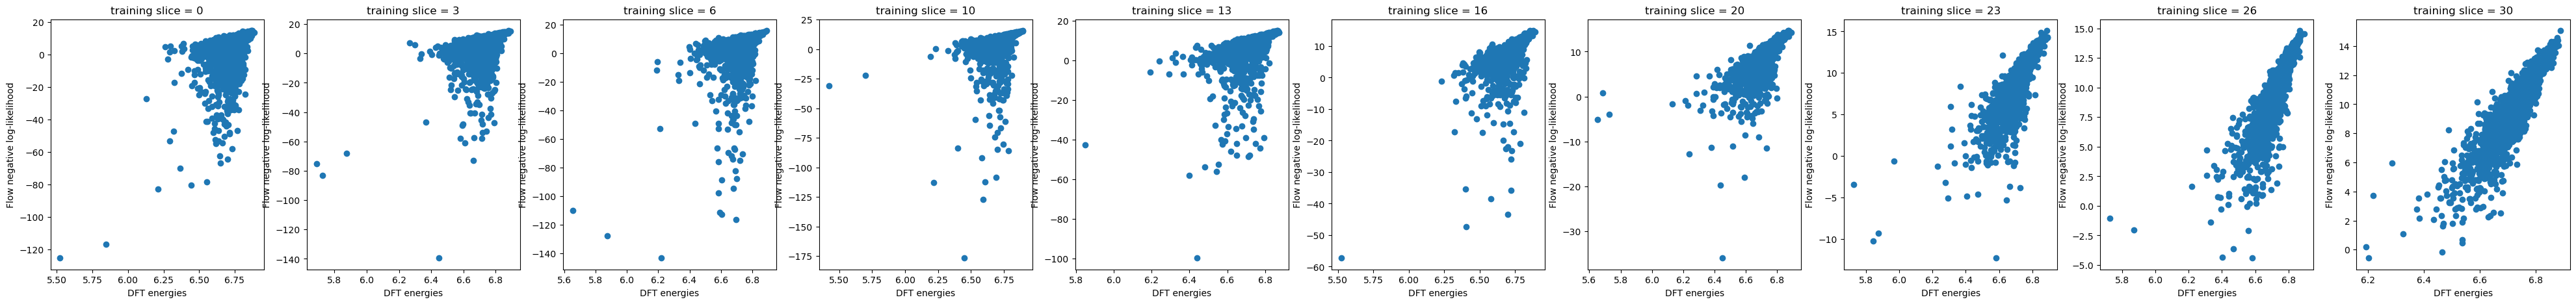

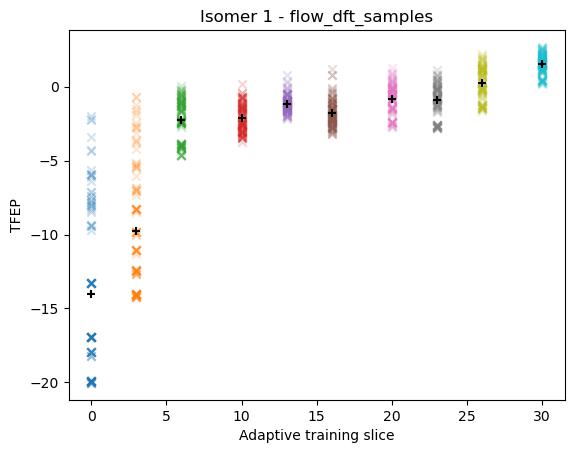

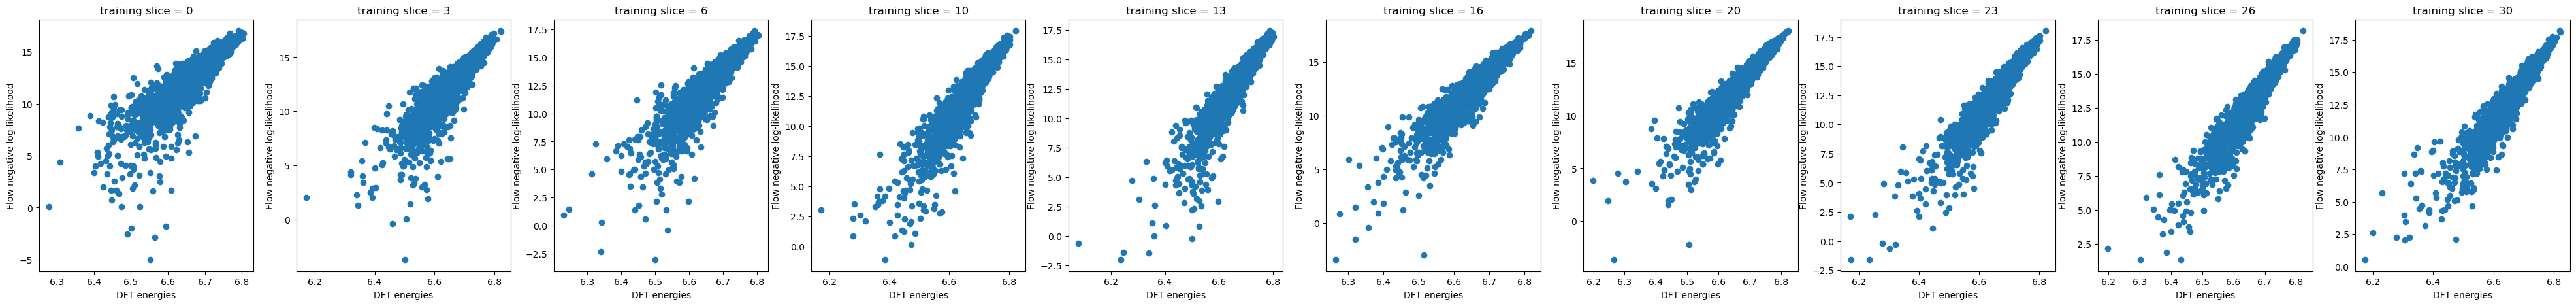

In [11]:
# flow that has been trained by dft 
kind = 'flow_dft_samples'
# Actually here there is an issue - which is that the configurations are generated from the final flow a priori only
n_train_slice = 10
# train_slice = 10
n_samples = 2000


for isomer_id in mode_labels:
    runs = adaptive_dft_dics[isomer_id]['dict_flows_training']
    train_slices = (np.linspace(0, len(runs)-1, n_train_slice)).astype(int)

    models = [runs[t][0]['models'][-1] for t in train_slices]

    prop_samples, energy_target = load_samples_n_energies(kind, isomer_id)
    print('Number of dft computed:', energy_target.shape[0])

    dic_results_TFPs = {}

    plt.figure()
    ax1 = plt.subplot(111)
    plt.title('Isomer {:d} - {:s}'.format(isomer_id, kind))
    plt.xlabel('Adaptive training slice')
    plt.ylabel('TFEP')

    plt.figure(figsize=(5 * n_train_slice, 5))
    axs = [plt.subplot(1, n_train_slice, i+1) for i in range(n_train_slice)]

    dic_results_TFPs[isomer_id] = {}
    dic_results_TFPs[isomer_id]['means'] = []
    dic_results_TFPs[isomer_id]['stds'] = []

    for t, train_slice in enumerate(train_slices):
        log_ratio_0_TFPs = []
        log_err_0_TFPs = []

        for trial in range(100):
            idx = np.random.choice(energy_target.shape[0], n_samples, replace=False)

            logprob_prop = (- models[t].nll(prop_samples[idx])).detach()
            logprob_target = (-energy_target[idx]).detach()
            logr_TFP_0, log_err_TFP_0 = compute_TFP_from_samples(logprob_prop, logprob_target)
            log_ratio_0_TFPs.append(logr_TFP_0)
            log_err_0_TFPs.append(log_err_TFP_0)

            
        dic_results_TFPs[isomer_id]['means'].append(np.array(log_ratio_0_TFPs).mean())
        dic_results_TFPs[isomer_id]['stds'].append(np.array(log_ratio_0_TFPs).std())

        plt.sca(ax1)
        plt.scatter(np.ones(len(log_ratio_0_TFPs))*train_slice, log_ratio_0_TFPs, marker='x', alpha=0.2)
        plt.scatter(train_slice, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')
        

        plt.sca(axs[t])
        plt.scatter(logprob_target, logprob_prop)
        plt.xlabel('DFT energies')
        plt.ylabel('Flow negative log-likelihood')
        plt.title('training slice = {:d}'.format(train_slice))
# for isomer in mode_labels:
#     prop_samples, energy_target = load_samples_n_energies(kind, isomer)

#     logprob_prop =  
#     logprob_target = -energy_target

# compute_TFP_from_samples(logprob_prop, logprob_target)

Number of dft computed: 10000
Number of dft computed: 10000


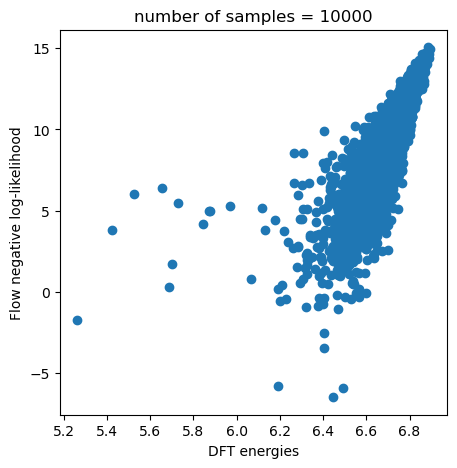

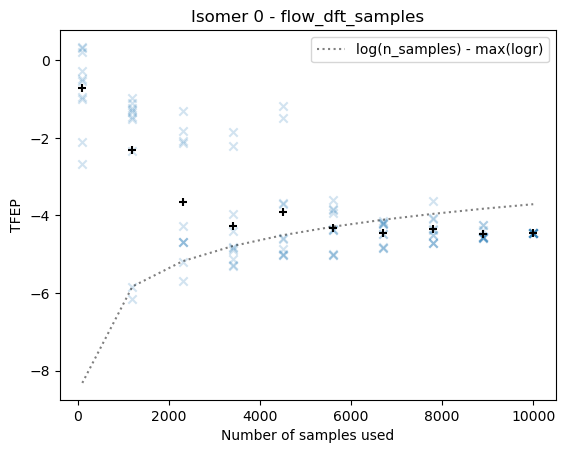

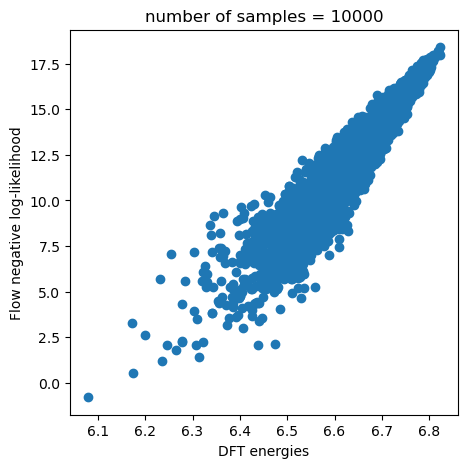

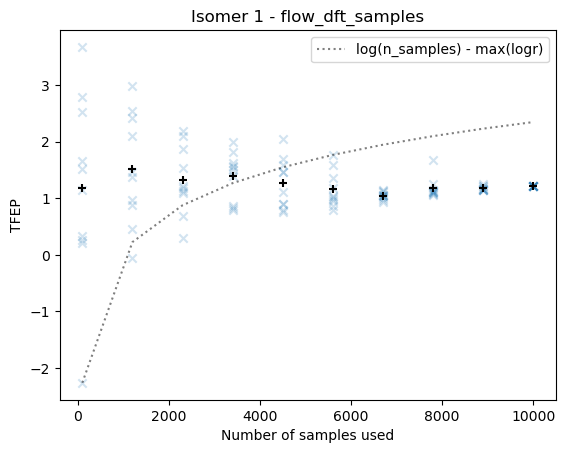

In [83]:
# flow that has been trained by dft 
kind = 'flow_dft_samples'
# Actually here there is an issue - which is that the configurations are generated from the final flow a priori only
# n_train_slice = 10
# train_slice = 10
# n_samples = 2000
n_sampless = np.linspace(100, 10000, 10).astype(int)

dic_results_TFPs = {}
for isomer_id in mode_labels:
    runs = adaptive_dft_dics[isomer_id]['dict_flows_training']
    model = runs[-1][0]['models'][-1]

    # train_slices = (np.linspace(0, len(runs)-1, n_train_slice)).astype(int)
    # models = [runs[t][0]['models'][-1] for t in train_slices]

    prop_samples, energy_target = load_samples_n_energies(kind, isomer_id)
    print('Number of dft computed:', energy_target.shape[0])

    plt.figure()
    ax1 = plt.subplot(111)
    plt.title('Isomer {:d} - {:s}'.format(isomer_id, kind))
    plt.xlabel('Number of samples used')
    plt.ylabel('TFEP')

    dic_results_TFPs[isomer_id] = {}
    dic_results_TFPs[isomer_id]['means'] = []
    dic_results_TFPs[isomer_id]['stds'] = []

    for nn, n_samples in enumerate(n_sampless):
        log_ratio_0_TFPs = []
        log_err_0_TFPs = []

        for trial in range(10):
            idx = np.random.choice(energy_target.shape[0], n_samples, replace=False)

            # logprob_prop = (- models[t].nll(prop_samples[idx])).detach()
            logprob_prop = (- model.nll(prop_samples[idx])).detach()
            logprob_target = (-energy_target[idx]).detach()
            logr_TFP_0, log_err_TFP_0 = compute_TFP_from_samples(logprob_prop, logprob_target)
            log_ratio_0_TFPs.append(logr_TFP_0)
            log_err_0_TFPs.append(log_err_TFP_0)

            
        dic_results_TFPs[isomer_id]['means'].append(np.array(log_ratio_0_TFPs).mean())
        dic_results_TFPs[isomer_id]['stds'].append(np.array(log_ratio_0_TFPs).std())

        plt.sca(ax1)
        plt.scatter(np.ones(len(log_ratio_0_TFPs))*n_samples, log_ratio_0_TFPs, marker='x', c='C0', alpha=0.2)
        plt.scatter(n_samples, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')
        
    plt.figure(figsize=(5, 5))
    ax2 = plt.subplot(1,1,1)
    plt.sca(ax2)
    plt.scatter(logprob_target, logprob_prop)
    plt.xlabel('DFT energies')
    plt.ylabel('Flow negative log-likelihood')
    plt.title('number of samples = {:d}'.format(n_samples))

    #Compute the TFEP estimate if one saample dominates
    n_prop = logprob_prop.shape[0]
    logprob_prop = (- model.nll(prop_samples)).detach()
    logprob_target = (-energy_target).detach()
    logr_per_sample = logprob_target - logprob_prop
    max = torch.max(logr_per_sample).item()
    plt.sca(ax1)
    plt.plot(n_sampless, np.log(n_sampless)-max, c='k', ls=':', alpha=0.5, label='log(n_samples) - max(logr)')
    plt.legend()
# for isomer in mode_labels:
#     prop_samples, energy_target = load_samples_n_energies(kind, isomer)

#     logprob_prop =  
#     logprob_target = -energy_target

# compute_TFP_from_samples(logprob_prop, logprob_target)

# Saving the result to a make fool plot
dic_results_TFPs_flow_dft = dic_results_TFPs
dic_results_TFPs_flow_dft['n_samples'] = copy.copy(n_sampless)

### 1.2 Flows trained on MD

In [48]:
## NOT SURE WHERE I SHOULD FIND THE PROPER MODELS# md_dics[isomer_id]['model']

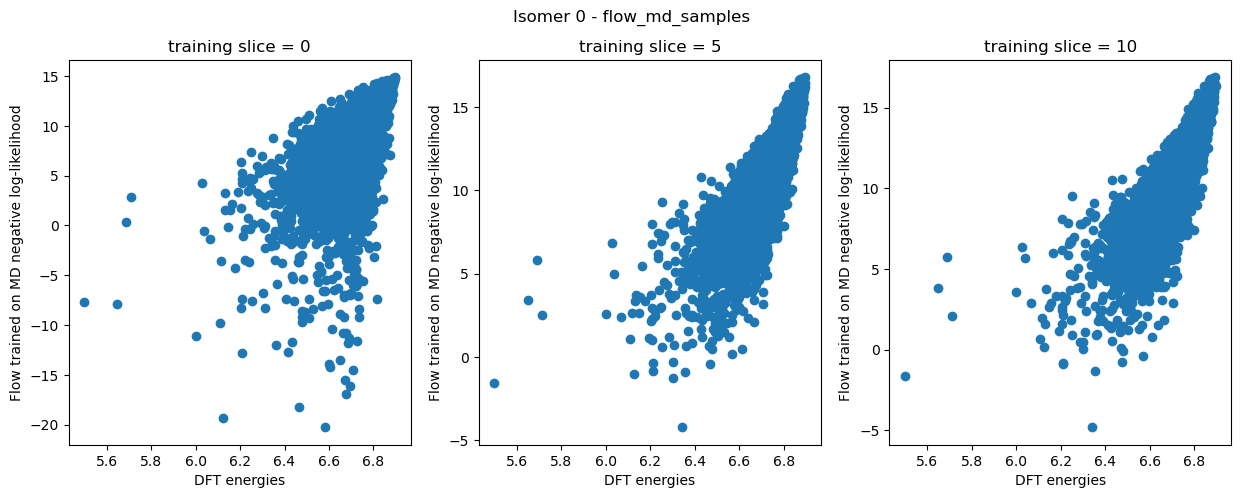

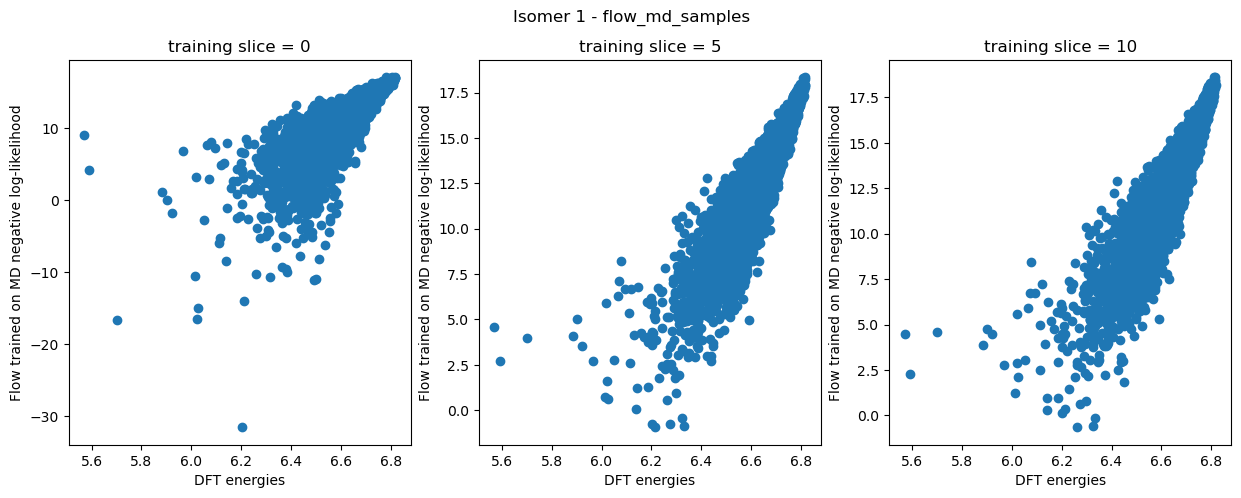

In [55]:
kind = 'flow_md_samples'
n_train_slice = 3
train_slices = (np.linspace(0, len(models)-1, n_train_slice)).astype(int)

for isomer_id in mode_labels:
        plt.figure(figsize=(5 * n_train_slice, 5))
        plt.suptitle('Isomer {:d} - {:s}'.format(isomer_id, kind))
        axs = [plt.subplot(1, n_train_slice, i+1) for i in range(n_train_slice)]
        # models = load_pickle_file(flow_md_path[isomer_id], path=DFT_SIMS_PATH)['models']
        models = md_dics[isomer_id]['models']
        # len(models)

        prop_samples, energy_target = load_samples_n_energies(kind, isomer_id)

        for t, train_slice in enumerate(train_slices):
                
                model = models[train_slice]
                logprob_prop = (- model.nll(prop_samples)).detach()
                plt.sca(axs[t])
                plt.scatter(-energy_target, logprob_prop)
                plt.xlabel('DFT energies')
                plt.ylabel('Flow trained on MD negative log-likelihood')
                plt.title('training slice = {:d}'.format(train_slice))

Number of dft computed: 10000
Number of dft computed: 10000


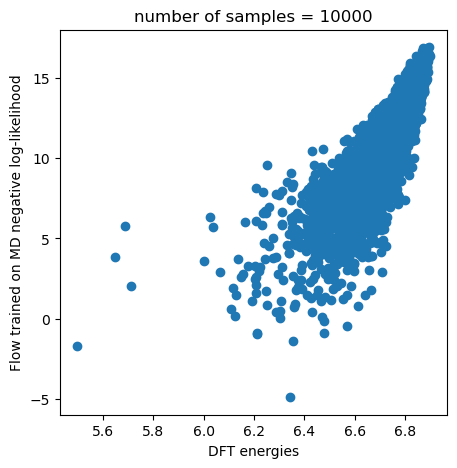

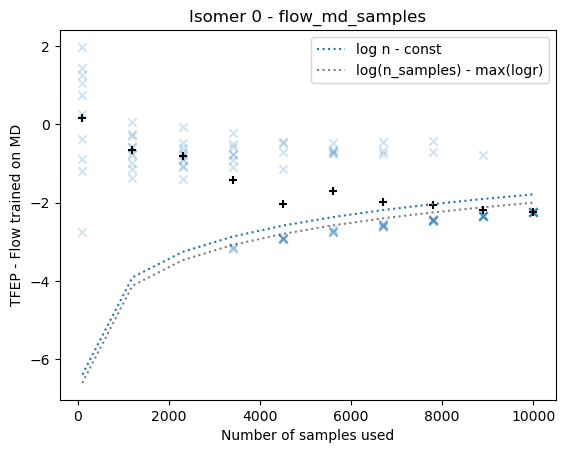

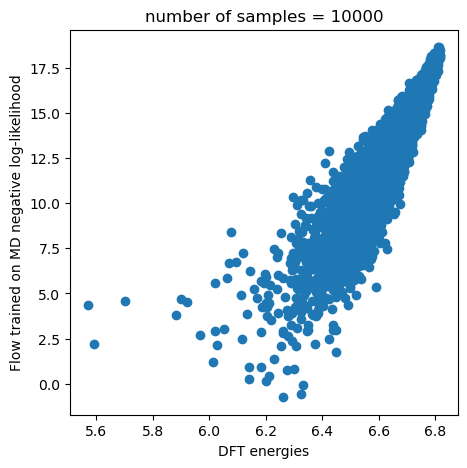

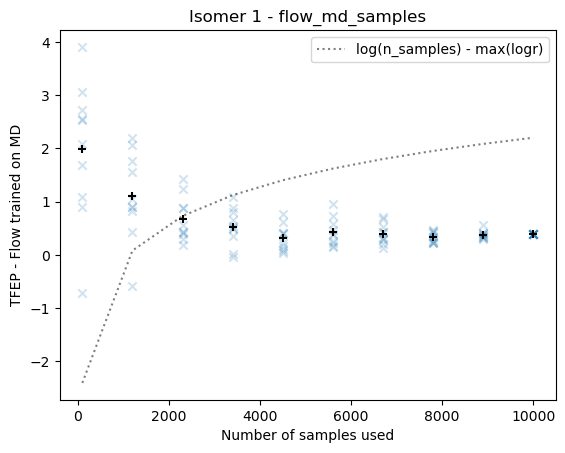

In [84]:
# flow that has been trained by dft 
kind = 'flow_md_samples'
# Actually here there is an issue - which is that the configurations are generated from the final flow a priori only
# n_train_slice = 10
# train_slice = 10
# n_samples = 2000
n_sampless = np.linspace(100, 10000, 10).astype(int)

dic_results_TFPs = {}
for isomer_id in mode_labels:
    model = md_dics[isomer_id]['model']

    # train_slices = (np.linspace(0, len(runs)-1, n_train_slice)).astype(int)
    # models = [runs[t][0]['models'][-1] for t in train_slices]

    prop_samples, energy_target = load_samples_n_energies(kind, isomer_id)
    print('Number of dft computed:', energy_target.shape[0])

    plt.figure()
    ax1 = plt.subplot(111)
    plt.title('Isomer {:d} - {:s}'.format(isomer_id, kind))
    plt.xlabel('Number of samples used')
    plt.ylabel('TFEP - Flow trained on MD')

    dic_results_TFPs[isomer_id] = {}
    dic_results_TFPs[isomer_id]['means'] = []
    dic_results_TFPs[isomer_id]['stds'] = []

    for nn, n_samples in enumerate(n_sampless):
        log_ratio_0_TFPs = []
        log_err_0_TFPs = []

        for trial in range(10):
            idx = np.random.choice(energy_target.shape[0], n_samples, replace=False)

            # logprob_prop = (- models[t].nll(prop_samples[idx])).detach()
            logprob_prop = (- model.nll(prop_samples[idx])).detach()
            logprob_target = (-energy_target[idx]).detach()
            logr_TFP_0, log_err_TFP_0 = compute_TFP_from_samples(logprob_prop, logprob_target)
            log_ratio_0_TFPs.append(logr_TFP_0)
            log_err_0_TFPs.append(log_err_TFP_0)

            
        dic_results_TFPs[isomer_id]['means'].append(np.array(log_ratio_0_TFPs).mean())
        dic_results_TFPs[isomer_id]['stds'].append(np.array(log_ratio_0_TFPs).std())

        plt.sca(ax1)
        plt.scatter(np.ones(len(log_ratio_0_TFPs))*n_samples, log_ratio_0_TFPs, marker='x', c='C0', alpha=0.2)
        plt.scatter(n_samples, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')
    
    if isomer_id == 0:
        plt.plot(n_sampless, np.log(n_sampless)-11, ':', label= 'log n - const')
        plt.legend()
        
    plt.figure(figsize=(5, 5))
    ax2 = plt.subplot(1,1,1)
    plt.sca(ax2)
    plt.scatter(logprob_target, logprob_prop)
    plt.xlabel('DFT energies')
    plt.ylabel('Flow trained on MD negative log-likelihood')
    plt.title('number of samples = {:d}'.format(n_samples))


    #Compute the TFEP lower bound given a set of samples 
    n_prop = logprob_prop.shape[0]
    logprob_prop = (- model.nll(prop_samples)).detach()
    logprob_target = (-energy_target).detach()
    logr_per_sample = logprob_target - logprob_prop
    max = torch.max(logr_per_sample).item()
    plt.sca(ax1)
    plt.plot(n_sampless, np.log(n_sampless)-max, c='k', ls=':', alpha=0.5, label='log(n_samples) - max(logr)')
    plt.legend()

# for isomer in mode_labels:
#     prop_samples, energy_target = load_samples_n_energies(kind, isomer)

#     logprob_prop =  
#     logprob_target = -energy_target

# compute_TFP_from_samples(logprob_prop, logprob_target)
dic_results_TFPs_flow_md = dic_results_TFPs
dic_results_TFPs_flow_md['n_samples'] = n_sampless

#### Investigating the outliers that make log_n + constant lower bound

(array([0.04206895, 0.03301403, 0.01727206, 0.02033163, 0.02127393,
        0.00834747, 0.00655076, 0.00514077, 0.        , 0.00158297,
        0.00124225, 0.        , 0.00076504, 0.        , 0.00047115,
        0.        , 0.        , 0.        , 0.00017869]),
 array([  10.        ,   12.74274986,   16.23776739,   20.69138081,
          26.36650899,   33.59818286,   42.81332399,   54.55594781,
          69.51927962,   88.58667904,  112.88378917,  143.84498883,
         183.29807108,  233.57214691,  297.63514416,  379.26901907,
         483.29302386,  615.84821107,  784.75997035, 1000.        ]),
 <BarContainer object of 19 artists>)

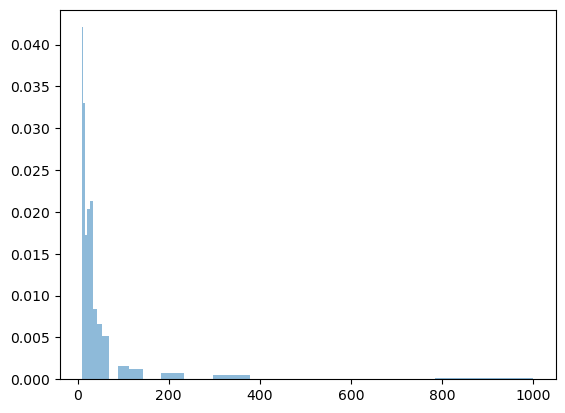

In [78]:

isomer_id = 0
model = md_dics[isomer_id]['model']

# train_slices = (np.linspace(0, len(runs)-1, n_train_slice)).astype(int)
# models = [runs[t][0]['models'][-1] for t in train_slices]
prop_samples, energy_target = load_samples_n_energies(kind, isomer_id) 
n_prop = prop_samples.shape[0]
log_prob_target = -energy_target
log_prob_prop = (- model.nll(prop_samples)).detach()
logr_per_sample = logprob_target - logprob_prop
# logr = - logsumexp(logr_per_sample) + np.log(n_prop)
bins = np.logspace(1, 3, 20)
plt.hist(np.exp(logr_per_sample),bins=bins, alpha=0.5, label=kind, density=True)

### 1.3 Flows trained on DFT+MLP 

In [106]:
adaptive_dft_mlp_dics[isomer_id]['dict_flows_training'][-1][1]['losses']
# [0]['dict_flows_training'][0][0].keys()

tensor([[-12.5784, -12.5976, -12.6064, -12.6144, -12.6218, -12.6287, -12.6343,
         -12.6395, -12.6441, -12.6486, -12.6527, -12.6570, -12.6608, -12.6645,
         -12.6680, -12.6714, -12.6747, -12.6780, -12.6812, -12.6843, -12.6874,
         -12.6903, -12.6933, -12.6963, -12.6991, -12.7019, -12.7046, -12.7073,
         -12.7099, -12.7125, -12.7149, -12.7175, -12.7199, -12.7222, -12.7245,
         -12.7268, -12.7291, -12.7313, -12.7335, -12.7356, -12.7378, -12.7399,
         -12.7420, -12.7441, -12.7461, -12.7482, -12.7502, -12.7522, -12.7542,
         -12.7563, -12.7581, -12.7601, -12.7620, -12.7639, -12.7658, -12.7677,
         -12.7695, -12.7714, -12.7733, -12.7752, -12.7770, -12.7789, -12.7807,
         -12.7825, -12.7843, -12.7861, -12.7879, -12.7896, -12.7913, -12.7930,
         -12.7946, -12.7964, -12.7980, -12.7996, -12.8012, -12.8028, -12.8044,
         -12.8060, -12.8075, -12.8091, -12.8105, -12.8121, -12.8136, -12.8150,
         -12.8165, -12.8180, -12.8194, -12.8208, -12

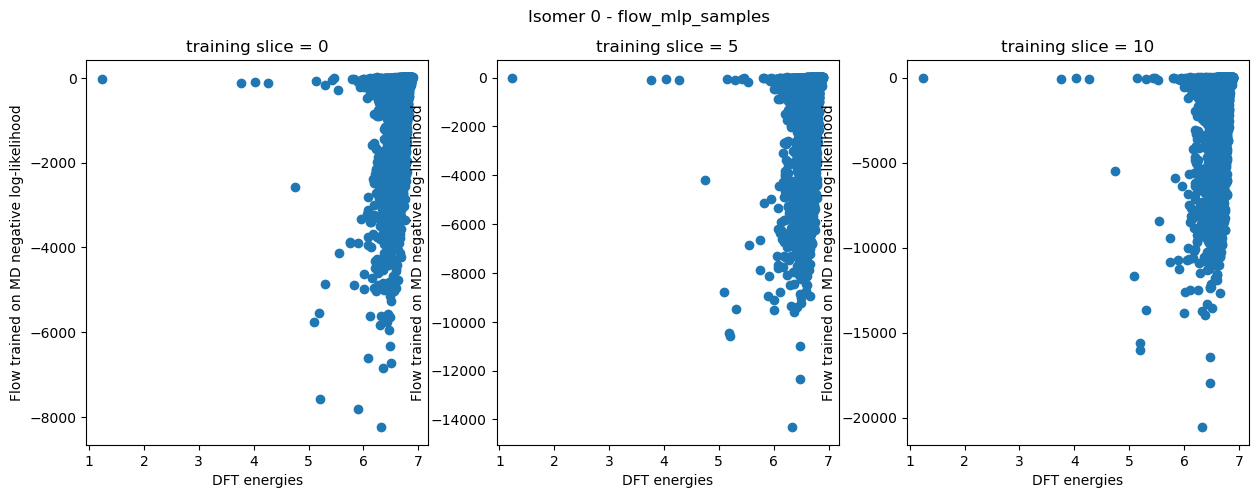

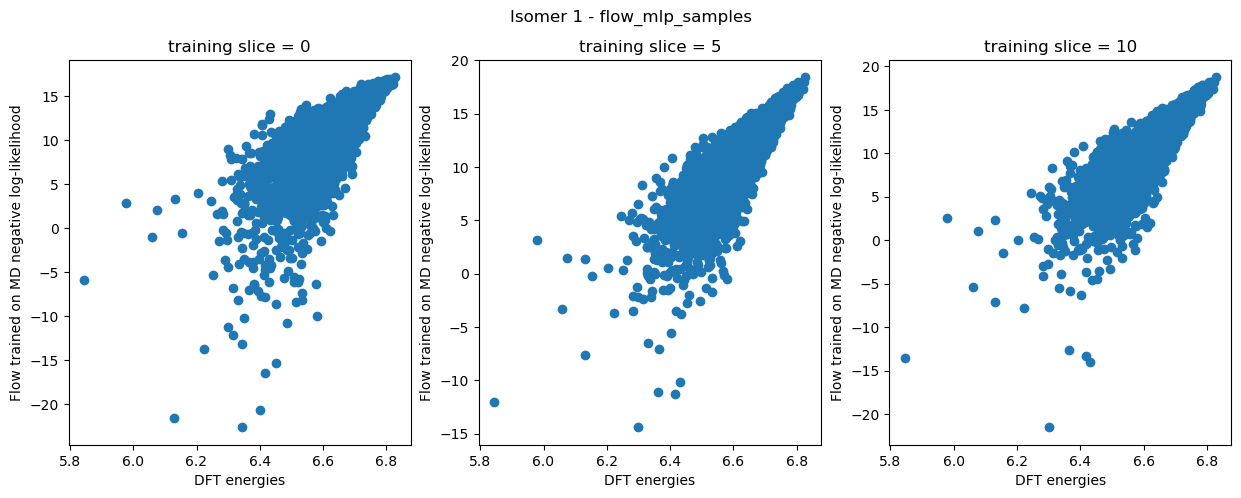

In [49]:
kind = 'flow_mlp_samples'
n_train_slice = 3


for isomer_id in mode_labels:
        plt.figure(figsize=(5 * n_train_slice, 5))
        plt.suptitle('Isomer {:d} - {:s}'.format(isomer_id, kind))
        axs = [plt.subplot(1, n_train_slice, i+1) for i in range(n_train_slice)]
        
        # TODO: find how to load the models
        # runs = adaptive_dft_dics[isomer_id]['dict_flows_training']
        # model = [ r[0]['models'][-1] for r in runs]
        # models = adaptive_dft_mlp_dics[isomer_id]['models']
        # models = md_dics[isomer_id]['models']
        # len(models)
        train_slices = (np.linspace(0, len(models)-1, n_train_slice)).astype(int)

        prop_samples, energy_target = load_samples_n_energies(kind, isomer_id)

        for t, train_slice in enumerate(train_slices):
                
                model = models[train_slice]
                logprob_prop = (- model.nll(prop_samples)).detach()
                plt.sca(axs[t])
                plt.scatter(-energy_target, logprob_prop)
                plt.xlabel('DFT energies')
                plt.ylabel('Flow trained on MD negative log-likelihood')
                plt.title('training slice = {:d}'.format(train_slice))

#TODO: compare with the estimate with the MLP energy

### 1.z Combining the plots

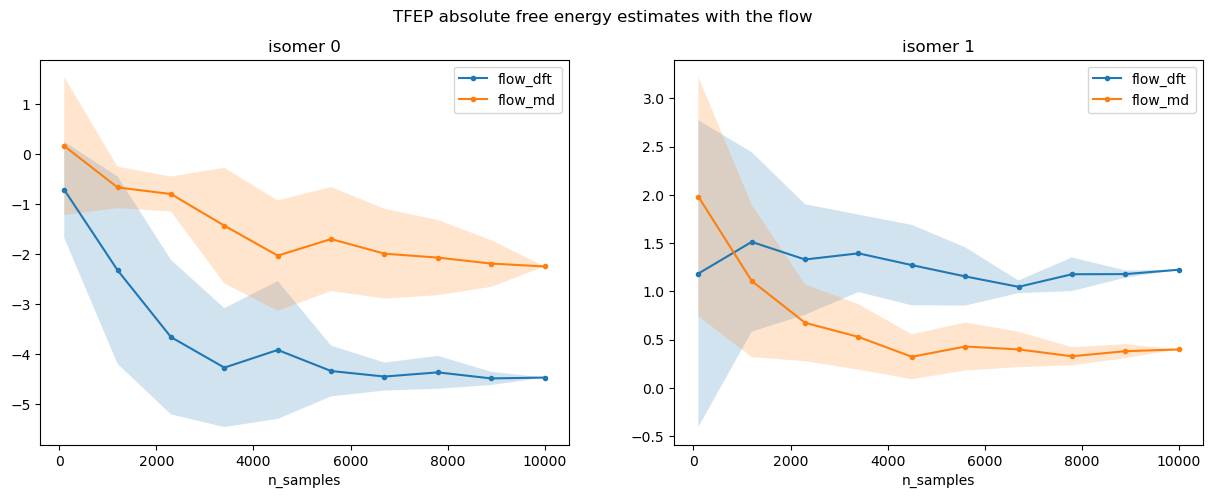

In [85]:
dic_results_TFPs_flow_dft
dic_results_TFPs_flow_md

plt.figure(figsize=(15, 5))
plt.suptitle('TFEP absolute free energy estimates with the flow')
axs = [plt.subplot(1, 2, i+1) for i in range(2)]
for isomer_id in mode_labels:
    plt.sca(axs[isomer_id])
    plt.title('isomer {:d}'.format(isomer_id))
    plt.plot(dic_results_TFPs_flow_dft['n_samples'],
                dic_results_TFPs_flow_dft[isomer_id]['means'],  '.-',
                label='flow_dft')
    plt.plot(dic_results_TFPs_flow_md['n_samples'], 
                dic_results_TFPs_flow_md[isomer_id]['means'], '.-',
                label='flow_md')
    #fill between
    plt.fill_between(dic_results_TFPs_flow_dft['n_samples'],
                    np.array(dic_results_TFPs_flow_dft[isomer_id]['means']) - np.array(dic_results_TFPs_flow_dft[isomer_id]['stds']),
                    np.array(dic_results_TFPs_flow_dft[isomer_id]['means']) + np.array(dic_results_TFPs_flow_dft[isomer_id]['stds']),
                    alpha=0.2)
    plt.fill_between(dic_results_TFPs_flow_md['n_samples'],
                    np.array(dic_results_TFPs_flow_md[isomer_id]['means']) - np.array(dic_results_TFPs_flow_md[isomer_id]['stds']),
                    np.array(dic_results_TFPs_flow_md[isomer_id]['means']) + np.array(dic_results_TFPs_flow_md[isomer_id]['stds']),
                    alpha=0.2)
    plt.legend()
    plt.xlabel('n_samples')

## 2 - BAR computations

In [18]:
# n_prop = 5

# dic_results_TFPs = {}

# for isomer_id in mode_labels:

#     dic_results_TFPs[isomer_id] = {}
#     dic_results_TFPs[isomer_id]['means'] = []
#     dic_results_TFPs[isomer_id]['stds'] = []

#     plt.figure()
#     plt.title('isomer {:d}'.format(isomer_id))
#     for r,run in enumerate(adaptives_dic[isomer_id]['dict_flows_training']):
#         flow = run[0]['models'][-1]
#         log_ratio_0_TFPs = []
#         log_err_0_TFPs = []

#         for trial in range(10):
#             logr_TFP_0, log_err_TFP_0 = compute_TFP(n_prop, target_log_probs[isomer_id], flow)
#             log_ratio_0_TFPs.append(logr_TFP_0)
#             log_err_0_TFPs.append(log_err_TFP_0)
        
#         dic_results_TFPs[isomer_id][r] = (log_ratio_0_TFPs, log_err_0_TFPs)
        
#         plt.scatter(np.ones(len(log_ratio_0_TFPs))*r, log_ratio_0_TFPs, marker='x', alpha=0.2)
#         plt.scatter(r, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')

#         dic_results_TFPs[isomer_id]['means'].append(np.array(log_ratio_0_TFPs).mean())
#         dic_results_TFPs[isomer_id]['stds'].append(np.array(log_ratio_0_TFPs).std())
    
#     plt.errorbar(np.arange(len(dic_results_TFPs[isomer_id]['means'])), dic_results_TFPs[isomer_id]['means'], yerr=dic_results_TFPs[isomer_id]['stds'], fmt='o')
       

#     plt.xlabel('adaptive mcmc retraining stage')
#     plt.ylabel('log ratio by Targeted Free energy Perturbation (TFP)')

#     # print('logr_TFP {:.3e} +/- {:.3e}'.format(np.array(log_ratio_0_TFPs).mean(), np.array(log_ratio_0_TFPs).std()))

: 

: 

: 